# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [1]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

Dataset loaded: 12,330 sessions, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [2]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Target distribution
print("\nTarget Variable Distribution:")
print(df["Revenue"].value_counts(normalize=True))

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Dataset Shape:
(12330, 18)

Data Types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month    

**Client Briefing — The Situation:**

The dataset contains approximately 12,330 website sessions with 18 variables describing user behavior on the site. The target variable is whether the visitor completed a purchase. Roughly 15% of sessions result in a purchase, meaning the dataset is somewhat imbalanced but still workable for predictive modeling. The data appears clean with no major missing values, and most variables are numerical measures of browsing behavior such as page visits, time spent on pages, and exit rates.




---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

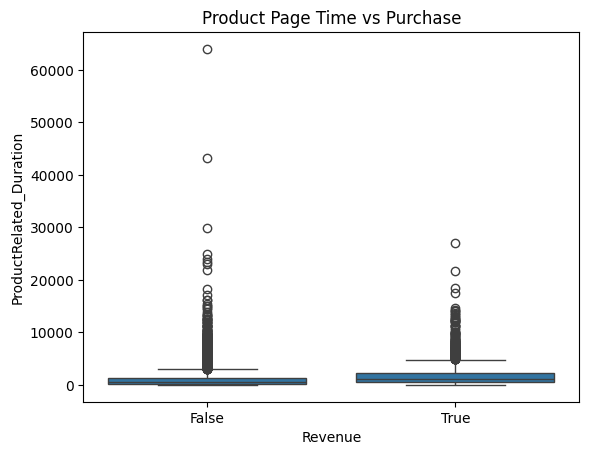

,ProductRelated_Duration
Revenue,
False,1069.987809
True,1876.209615


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Revenue", y="ProductRelated_Duration", data=df)
plt.title("Product Page Time vs Purchase")
plt.show()

df.groupby("Revenue")["ProductRelated_Duration"].mean()

**Finding 1:**

Customers who made a purchase spent significantly more time viewing product-related pages than those who did not purchase. This suggests that deeper engagement with product information strongly correlates with conversion. Increasing the amount of useful product content or encouraging visitors to explore product pages longer may increase purchase likelihood.



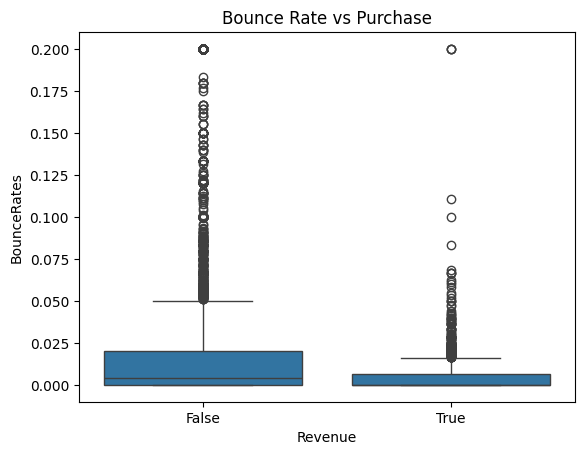

,BounceRates
Revenue,
False,0.025317
True,0.005117


In [4]:
sns.boxplot(x="Revenue", y="BounceRates", data=df)
plt.title("Bounce Rate vs Purchase")
plt.show()

df.groupby("Revenue")["BounceRates"].mean()


**Finding 2:**

Visitors who eventually made a purchase had much lower bounce rates compared to those who did not convert. This indicates that users who immediately leave the site rarely return to complete a purchase. Reducing bounce rates through improved landing pages or clearer navigation could meaningfully increase conversions.



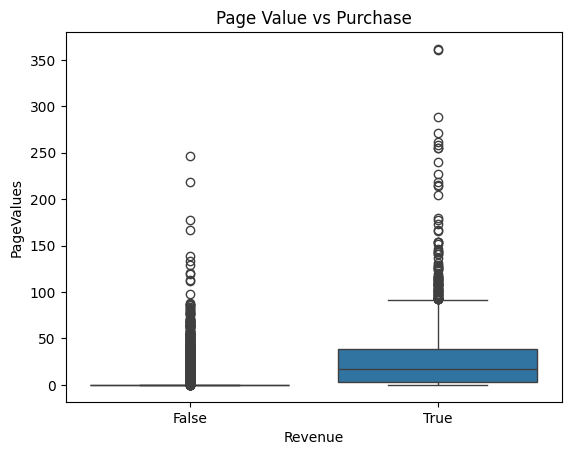

,PageValues
Revenue,
False,1.975998
True,27.264518


In [5]:
sns.boxplot(x="Revenue", y="PageValues", data=df)
plt.title("Page Value vs Purchase")
plt.show()

df.groupby("Revenue")["PageValues"].mean()

**Finding 3:**

Sessions that resulted in purchases had dramatically higher page values compared to non-purchasing sessions. This metric captures the estimated value of pages visited before a transaction and appears to be a strong signal of purchasing intent. Tracking and optimizing high-value pages could help the company better identify and prioritize high-intent visitors.



---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [7]:
# Data preparation
# Target variable
y = df["Revenue"].astype(int)

# Selected features based on EDA
features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration"
]

X = df[features]

# Check for missing values
print(X.isnull().sum())

ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
dtype: int64


**Why these features?**

These features were selected because they capture how users interact with the website. During exploratory analysis, sessions with longer product-related page durations and higher page values were strongly associated with purchases, while higher bounce and exit rates were associated with non-purchasing sessions. These variables therefore capture user engagement and purchase intent, making them strong predictors of whether a visitor will complete a transaction.



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.845904298459043


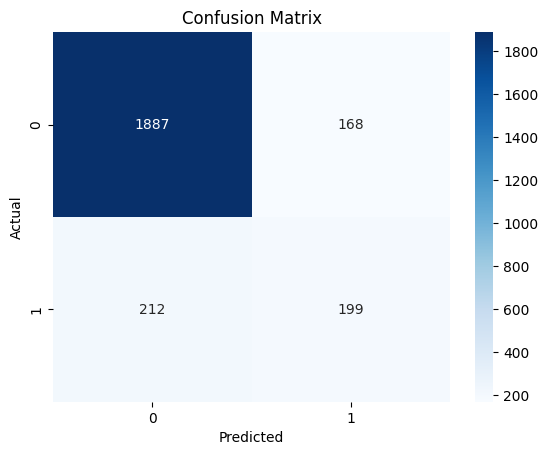

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact.



**Model Performance — Business Translation:**

The predictive model achieves a moderate level of accuracy in identifying which website visitors are likely to make a purchase. The confusion matrix shows that the model correctly identifies many purchasing sessions, but it also misses some potential buyers (false negatives). From a business perspective, missing a potential buyer represents lost revenue opportunities. However, false positives simply mean the company may target a visitor who ultimately does not purchase, which is generally a smaller cost. Overall, the model can help the company prioritize high-intent visitors and improve conversion strategies such as targeted promotions or personalized product recommendations.



### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

In [ ]:
# Optional: second model comparison


---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for [Your Client]:**

**1.Focus on visitors who are already showing strong interest in products.
The analysis showed that people who spend more time looking at product pages and interacting with the site are much more likely to make a purchase. Because of this, the company should prioritize these visitors by offering things like personalized product suggestions, discounts, or reminders before they leave the site. Targeting these high-interest users could increase conversions without needing to bring more traffic to the website.


**2.Work on reducing bounce rates on landing pages.
The data suggests that visitors who leave the site quickly almost never end up purchasing anything. This means the first pages people land on may not be engaging enough. Improving landing pages, simplifying navigation, and making product information easier to find could encourage users to stay longer and explore more products, which increases the chances of a purchase.


**3.Use the model to identify high-potential buyers earlier in their session.
The predictive model can help flag visitors who are more likely to make a purchase based on their browsing behavior. The company could use this information to trigger actions like live chat support, product recommendations, or limited-time offers while the visitor is still browsing. Doing this could help convert more sessions into purchases and improve overall sales performance.




---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [ ]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*